# Impairment Probability of Default (PD) Model Development

This notebook demonstrates a 3-step showcase for developing an impairment PD model:
1. **Data Simulation** — Generate 10,000 synthetic loan-level observations
2. **Default Event Simulation** — Score each observation and simulate a binary default flag (5% default rate)
3. **Model Fitting** — Fit a logistic regression model to predict default

In [2]:
! pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------  9.4/9.6 MB 71.5 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 63.8 MB/s  0:00:00

   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- -----------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from scipy.special import expit
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

---
## Step 1: Data Simulation

Generate 10,000 synthetic observations with seven raw features, then engineer four piecewise-linear spline terms from `perf_rel_t` at knots 2, 3, and 18.

In [28]:
np.random.seed(42)
n_samples = 10000

# ── Raw features ──────────────────────────────────────────────────────────────
df = pd.DataFrame({
    'time_since_obs': np.clip(np.random.exponential(scale=25, size=n_samples), 1, 84).astype(int),
    'ct_open_cards': np.clip(np.random.normal(1.068551, 0.595350, n_samples), 0, 2.079442),
    'ct_inquiries': np.clip(np.random.exponential(scale=2, size=n_samples), 0, 15).astype(int),
    'fico': np.clip(np.random.normal(2825, 1495, n_samples), 442, 6132),
    'utilization': np.clip(np.random.normal(1.74, 0.65, n_samples), 1.06, 2.87),
    'ct_latefee': np.clip(np.random.poisson(2, n_samples), 0, 5),
    'UR_3MGR_L6': np.clip(np.random.normal(-0.02, 0.038, n_samples), -0.156, 0.204),
})

# ── Piecewise-linear spline transforms of perf_rel_t ─────────────────────────
x = df['time_since_obs']

# T1 = min(x, 2)  — capped at 2
xi = x.fillna(0, inplace=False).copy()
xi[x >= 2] = 2
df['perf_rel_t_T1'] = xi

# T2 = min(max(0, x - 2), 1)  — knot at 2, capped at 1
xi = x.fillna(0, inplace=False)
xi = xi.apply(lambda v: 0 if v <= 2 else v - 2)
xi.clip(upper=1, inplace=True)
df['perf_rel_t_T2'] = xi

# T3 = min(max(0, x - 3), 15)  — knot at 3, capped at 15
xi = x.fillna(0, inplace=False)
xi = xi.apply(lambda v: 0 if v <= 3 else v - 3)
xi.clip(upper=15, inplace=True)
df['perf_rel_t_T3'] = xi

# T4 = max(0, x - 18)  — knot at 18, uncapped
xi = x.fillna(0, inplace=False)
xi = xi.apply(lambda v: 0 if v <= 18 else v - 18)
df['perf_rel_t_T4'] = xi

print(f'Dataset shape: {df.shape}')
df.describe().round(4)

Dataset shape: (10000, 11)


,time_since_obs,ct_open_cards,ct_inquiries,fico,utilization,ct_latefee,UR_3MGR_L6,perf_rel_t_T1,perf_rel_t_T2,perf_rel_t_T3,perf_rel_t_T4
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,23.2471,1.0742,1.5127,2834.1725,1.7858,1.9804,-0.0203,1.9207,0.8841,9.7138,10.7285
std,21.6709,0.5514,1.9519,1418.9915,0.5413,1.3500,0.0382,0.2702,0.3201,6.0480,17.6442
min,1.0000,0.0000,0.0000,442.0000,1.0600,0.0000,-0.1560,1.0000,0.0000,0.0000,0.0000
25%,7.0000,0.6766,0.0000,1755.5759,1.3116,1.0000,-0.0461,2.0000,1.0000,4.0000,0.0000
50%,16.0000,1.0786,1.0000,2808.5546,1.7498,2.0000,-0.0199,2.0000,1.0000,13.0000,0.0000
75%,33.0000,1.4748,2.0000,3846.2036,2.1876,3.0000,0.0055,2.0000,1.0000,15.0000,15.0000
max,84.0000,2.0794,15.0000,6132.0000,2.8700,5.0000,0.1358,2.0000,1.0000,15.0000,66.0000


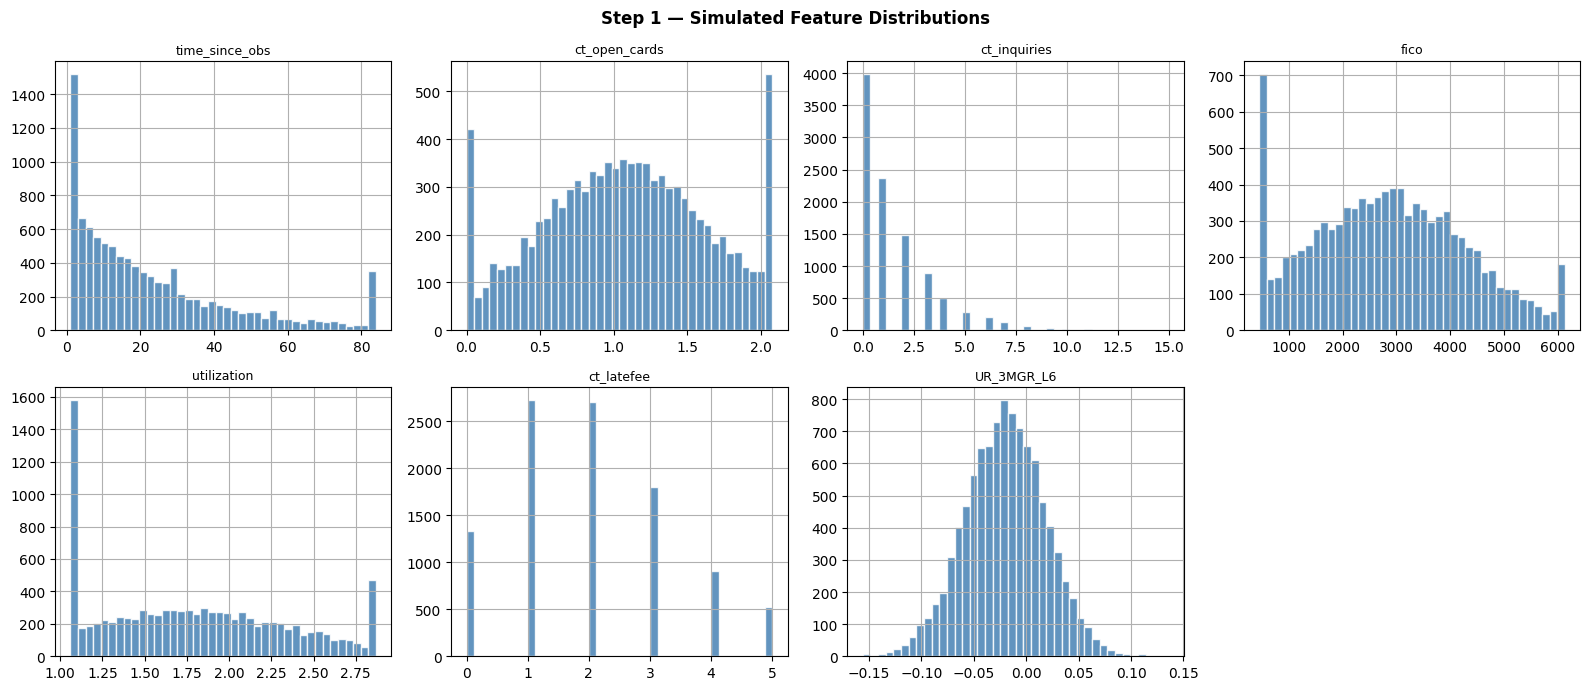

In [29]:
# Visualise key raw-feature distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
cols = ['time_since_obs', 'ct_open_cards', 'ct_inquiries',
        'fico', 'utilization', 'ct_latefee', 'UR_3MGR_L6']
for ax, col in zip(axes.flat, cols):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=9)
axes.flat[-1].set_visible(False)
fig.suptitle('Step 1 — Simulated Feature Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 2: Default Event Simulation

Apply the pre-estimated logistic regression coefficients to produce a linear predictor (log-odds score) for each observation.  
A small amount of Gaussian noise is added to introduce realistic randomness.  
The top-scoring **5%** of observations are labelled `default_event = 1`.

In [31]:
# ── Pre-estimated model coefficients ─────────────────────────────────────────
coef = {
    'const'              : -7.1430,
    'perf_rel_t_T1'      :  1.9057,
    'perf_rel_t_T2'      :  0.0157,
    'perf_rel_t_T3'      : -0.0303,
    'perf_rel_t_T4'      : -0.0054,
    'ct_open_cards' :  0.2352,
    'ct_inquiries' :  0.0329,
    'fico'         : -0.0004,
    'utilization'         :  0.4751,
    'ct_latefee'   :  0.1048,
    'UR_3MGR_L6':  3.3694,
}

# ── Compute linear predictor ─────────────────────────────────────────────────
score = coef['const']
for feat, weight in coef.items():
    if feat != 'const':
        score = score + weight * df[feat]

df['logit_score'] = score
df['pd_prob']     = expit(score)   # sigmoid → estimated PD

print(f"Score range  : [{score.min():.3f}, {score.max():.3f}]")
print(f"Raw PD range : [{df['pd_prob'].min():.4f}, {df['pd_prob'].max():.4f}]")
print(f"Mean raw PD  : {df['pd_prob'].mean():.4f}")

Score range  : [-7.012, -1.203]
Raw PD range : [0.0009, 0.2310]
Mean raw PD  : 0.0328


In [32]:
# ── Simulate default_event with ~5% default rate ──────────────────────────────
# Add Gaussian noise to the score so assignment is probabilistic, not deterministic
np.random.seed(42)
noise = np.random.normal(0, score.std() * 0.5, n_samples)
noisy_score = score + noise

n_defaults = int(round(0.05 * n_samples))          # exactly 500 defaults
default_idx = np.argsort(noisy_score)[-n_defaults:] # top-scoring rows → default

df['default_event'] = 0
df.loc[default_idx, 'default_event'] = 1

print(f"Total defaults : {df['default_event'].sum()}")
print(f"Default rate   : {df['default_event'].mean():.2%}")

Total defaults : 500
Default rate   : 5.00%


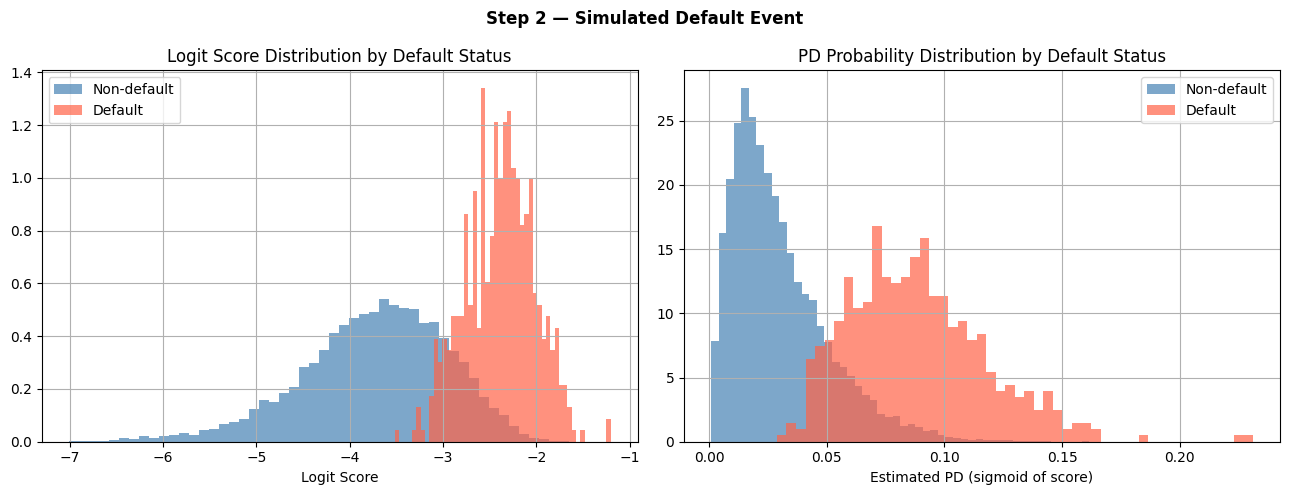

In [33]:
# Score distribution by default status
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for flag, label, color in [(0, 'Non-default', 'steelblue'), (1, 'Default', 'tomato')]:
    axes[0].hist(df.loc[df['default_event'] == flag, 'logit_score'],
                 bins=50, alpha=0.7, label=label, color=color, density=True)
axes[0].set_title('Logit Score Distribution by Default Status')
axes[0].set_xlabel('Logit Score')
axes[0].legend()

for flag, label, color in [(0, 'Non-default', 'steelblue'), (1, 'Default', 'tomato')]:
    axes[1].hist(df.loc[df['default_event'] == flag, 'pd_prob'],
                 bins=50, alpha=0.7, label=label, color=color, density=True)
axes[1].set_title('PD Probability Distribution by Default Status')
axes[1].set_xlabel('Estimated PD (sigmoid of score)')
axes[1].legend()

fig.suptitle('Step 2 — Simulated Default Event', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 3: Logistic Regression Model Fitting

Fit a logistic regression model using all 11 features created in Step 1 as predictors and `default_event` as the target.  
We use **statsmodels** for the full coefficient summary

In [34]:
# ── Define predictors (all columns created in Step 1) ────────────────────────
feature_cols = [
    # 'perf_rel_t_T1',
    'perf_rel_t_T2',
    'perf_rel_t_T3',
    'perf_rel_t_T4',
    'ct_open_cards',
    'ct_inquiries',
    'fico',
    'utilization',
    'ct_latefee',
    'UR_3MGR_L6',    
]
X = df[feature_cols]
y = df['default_event']

In [35]:
# ── statsmodels: full coefficient table with p-values ────────────────────────

families={
    "Bernoulli": sm.families.Binomial,
    "Gamma": sm.families.Gamma,
    "Norm": sm.families.Gaussian
}

links={
    "logit": sm.families.links.logit,
    "log": sm.families.links.log,
    "identity": sm.families.links.identity
}

dist="Bernoulli"
link="logit"
family=families[dist](links[link]())

X_sm = sm.add_constant(X)

reg_model = sm.GLM(y,X_sm, offset=None, family=family,var_weights=None, missing='drop').fit()
print(reg_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          default_event   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9990
Model Family:                Binomial   Df Model:                            9
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1104.7
Date:                Fri, 20 Mar 2026   Deviance:                       2209.4
Time:                        18:28:02   Pearson chi2:                 4.42e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1615
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -6.1900      0.358    -17.276

In [45]:
pred_score=reg_model.predict(sm.tools.add_constant(df[feature_cols],has_constant="add"))
pred_score.rename('pd_score',inplace=True)
pred_score.replace([np.inf, -np.inf],np.nan,inplace=True)
df_scored=pd.concat([df,pred_score],axis=1,sort=False)
df_scored['residual']=df_scored['pd_score']-df_scored['default_event']

## Step 4: Evaluate Model

VIF: Compute VIF foa all features.<br>
Blue --VIF <5<br>
Orange -- VIF 3-5<br>
Red --VIF >=5<br>

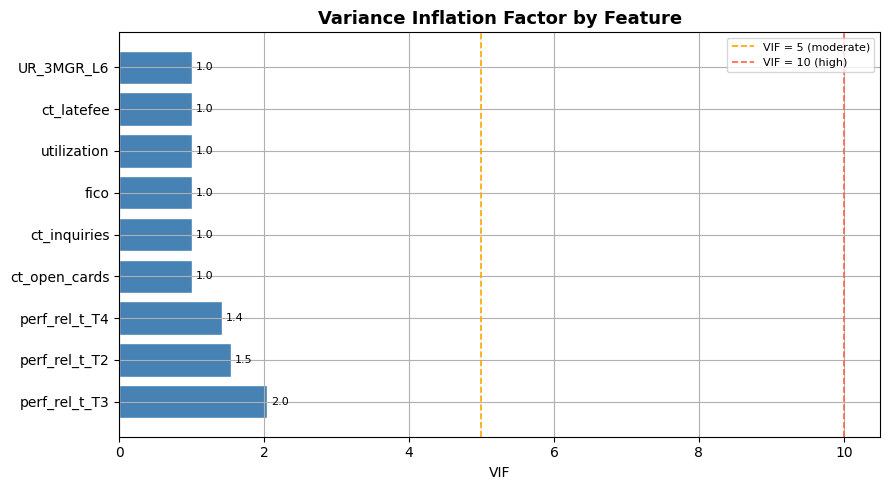


VIF Table:
                VIF
Feature            
perf_rel_t_T3  2.04
perf_rel_t_T2  1.54
perf_rel_t_T4  1.42
ct_open_cards  1.00
ct_inquiries   1.00
fico           1.00
utilization    1.00
ct_latefee     1.00
UR_3MGR_L6     1.00


In [23]:
# ── Variance Inflation Factor (VIF) for each feature ─────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X)
vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF'    : [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
}).set_index('Feature').drop('const')

vif_df['VIF'] = vif_df['VIF'].round(2)
vif_df = vif_df.sort_values('VIF', ascending=False)

# Colour-coded bar chart
colors = ['tomato' if v >= 5 else 'orange' if v >= 3 else 'steelblue' for v in vif_df['VIF']]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(vif_df.index, vif_df['VIF'], color=colors, edgecolor='white')
ax.axvline(5,  color='orange', linestyle='--', lw=1.2, label='VIF = 5 (moderate)')
ax.axvline(10, color='tomato',  linestyle='--', lw=1.2, label='VIF = 10 (high)')
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=8)
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor by Feature', fontsize=13, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('\nVIF Table:')
print(vif_df.to_string())

## Gini and Accuracy

In [47]:
# ── Overall Lift Ratio ────────────────────────────────────────────────────────
overall_default_rate = df_scored['default_event'].mean()

# Rank by pd_prob descending
ranked = df_scored[['pd_score', 'default_event']].sort_values('pd_score', ascending=False).reset_index(drop=True)
ranked['cum_pct_pop']      = (ranked.index + 1) / len(ranked)
ranked['cum_defaults']     = ranked['default_event'].cumsum()
ranked['cum_capture_rate'] = ranked['cum_defaults'] / ranked['default_event'].sum()
ranked['cum_default_rate'] = ranked['cum_defaults'] / (ranked.index + 1)
ranked['cum_lift']         = ranked['cum_default_rate'] / overall_default_rate

# Lift at standard thresholds
thresholds = [0.10, 0.20, 0.30, 0.50]
lift_summary = []
for t in thresholds:
    idx = int(t * len(ranked)) - 1
    row = ranked.iloc[idx]
    lift_summary.append({
        'Top % Population'   : f'{t:.0%}',
        'Defaults Captured'  : int(row['cum_defaults']),
        'Capture Rate'       : f"{row['cum_capture_rate']:.2%}",
        'Cum Default Rate'   : f"{row['cum_default_rate']:.2%}",
        'Lift Ratio'         : round(row['cum_lift'], 2),
    })

summary_df = pd.DataFrame(lift_summary)
print('Overall Lift Ratio Summary')
print('=' * 55)
print(f"Baseline default rate : {overall_default_rate:.2%}")
print(f"Total defaults        : {int(df_scored['default_event'].sum())}")
print()
print(summary_df.to_string(index=False))

# Gini coefficient (2 * AUC - 1) as a single overall discriminatory power measure
from sklearn.metrics import roc_auc_score
auc   = roc_auc_score(df_scored['default_event'], df_scored['pd_score'])
gini  = 2 * auc - 1
error = df_scored['residual'].sum()/df_scored['default_event'].sum()
print(f"\nAUC  : {auc:.4%}")
print(f"Gini : {gini:.4%}  (overall discriminatory power)")
print(f"Error : {error:.4%}  (overall error%)")

Overall Lift Ratio Summary
Baseline default rate : 5.00%
Total defaults        : 500

Top % Population  Defaults Captured Capture Rate Cum Default Rate  Lift Ratio
             10%                364       72.80%           36.40%        7.28
             20%                458       91.60%           22.90%        4.58
             30%                489       97.80%           16.30%        3.26
             50%                500      100.00%           10.00%        2.00

AUC  : 94.5736%
Gini : 89.1471%  (overall discriminatory power)
Error : -0.0000%  (overall error%)


Lift Plot:

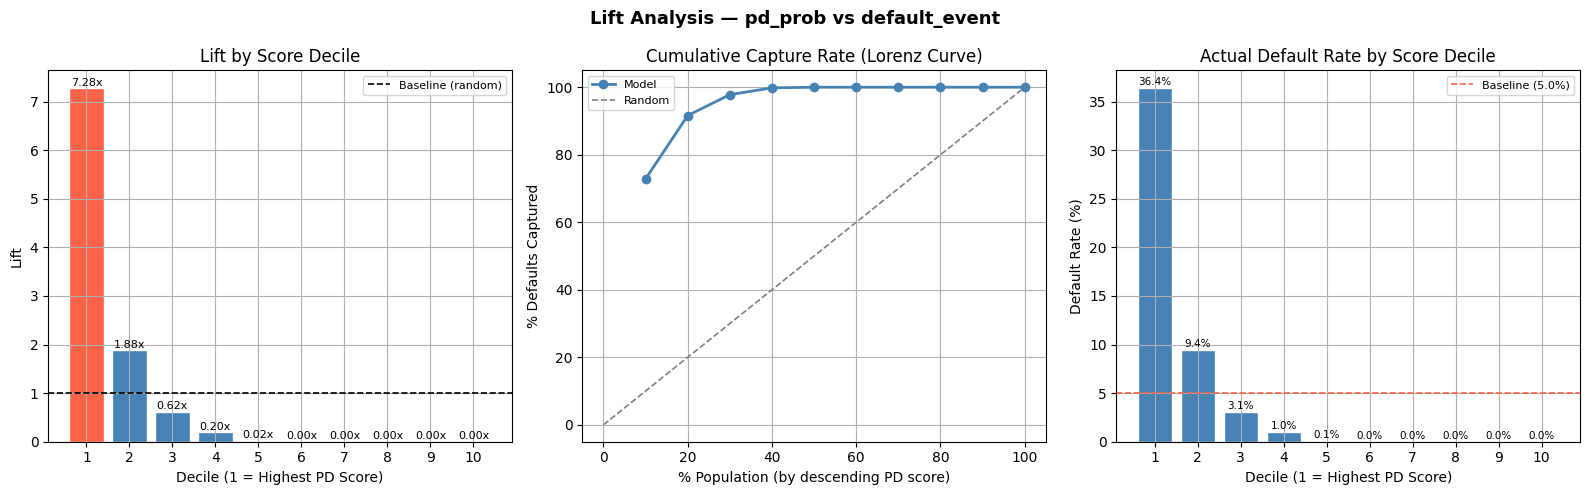


Lift Table by Decile:
        total  defaults  default_rate  lift  cum_capture_rate
decile                                                       
1        1000       364         0.364  7.28             0.728
2        1000        94         0.094  1.88             0.916
3        1000        31         0.031  0.62             0.978
4        1000        10         0.010  0.20             0.998
5        1000         1         0.001  0.02             1.000
6        1000         0         0.000  0.00             1.000
7        1000         0         0.000  0.00             1.000
8        1000         0         0.000  0.00             1.000
9        1000         0         0.000  0.00             1.000
10       1000         0         0.000  0.00             1.000


In [38]:
# ── Lift Chart: pd_prob discriminative power vs default_event ─────────────────
n_buckets = 10

lift_df = df_scored[['pd_score', 'default_event']].copy()
lift_df = lift_df.sort_values('pd_score', ascending=False).reset_index(drop=True)

# Assign decile buckets (1 = highest PD score, 10 = lowest)
lift_df['decile'] = pd.qcut(lift_df.index, q=n_buckets, labels=range(1, n_buckets + 1))

baseline_rate = lift_df['default_event'].mean()

bucket_stats = (
    lift_df.groupby('decile', observed=True)['default_event']
    .agg(total='count', defaults='sum')
    .assign(
        default_rate=lambda d: d['defaults'] / d['total'],
        lift=lambda d: (d['defaults'] / d['total']) / baseline_rate,
        cum_defaults=lambda d: d['defaults'].cumsum(),
        cum_pct_population=lambda d: d['total'].cumsum() / lift_df.shape[0],
        cum_capture_rate=lambda d: d['defaults'].cumsum() / d['defaults'].sum(),
    )
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Lift by decile ───────────────────────────────────────────────────
colors = ['tomato' if v >= 2 else 'steelblue' for v in bucket_stats['lift']]
axes[0].bar(bucket_stats.index.astype(str), bucket_stats['lift'], color=colors, edgecolor='white')
axes[0].axhline(1.0, color='black', linestyle='--', lw=1.2, label='Baseline (random)')
axes[0].set_xlabel('Decile (1 = Highest PD Score)')
axes[0].set_ylabel('Lift')
axes[0].set_title('Lift by Score Decile')
axes[0].legend(fontsize=8)
for i, (dec, row) in enumerate(bucket_stats.iterrows()):
    axes[0].text(i, row['lift'] + 0.05, f"{row['lift']:.2f}x", ha='center', fontsize=8)

# ── Panel 2: Default capture rate (cumulative) ────────────────────────────────
axes[1].plot(bucket_stats['cum_pct_population'] * 100,
             bucket_stats['cum_capture_rate'] * 100,
             marker='o', color='steelblue', lw=2, label='Model')
axes[1].plot([0, 100], [0, 100], color='grey', linestyle='--', lw=1.2, label='Random')
axes[1].set_xlabel('% Population (by descending PD score)')
axes[1].set_ylabel('% Defaults Captured')
axes[1].set_title('Cumulative Capture Rate (Lorenz Curve)')
axes[1].legend(fontsize=8)

# ── Panel 3: Default rate per decile ─────────────────────────────────────────
axes[2].bar(bucket_stats.index.astype(str), bucket_stats['default_rate'] * 100,
            color='steelblue', edgecolor='white')
axes[2].axhline(baseline_rate * 100, color='tomato', linestyle='--', lw=1.2,
                label=f'Baseline ({baseline_rate:.1%})')
axes[2].set_xlabel('Decile (1 = Highest PD Score)')
axes[2].set_ylabel('Default Rate (%)')
axes[2].set_title('Actual Default Rate by Score Decile')
axes[2].legend(fontsize=8)
for i, (dec, row) in enumerate(bucket_stats.iterrows()):
    axes[2].text(i, row['default_rate'] * 100 + 0.3,
                 f"{row['default_rate']:.1%}", ha='center', fontsize=7.5)

fig.suptitle('Lift Analysis — pd_prob vs default_event', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nLift Table by Decile:')
print(bucket_stats[['total', 'defaults', 'default_rate', 'lift', 'cum_capture_rate']].round(4).to_string())



Accuracc Plot

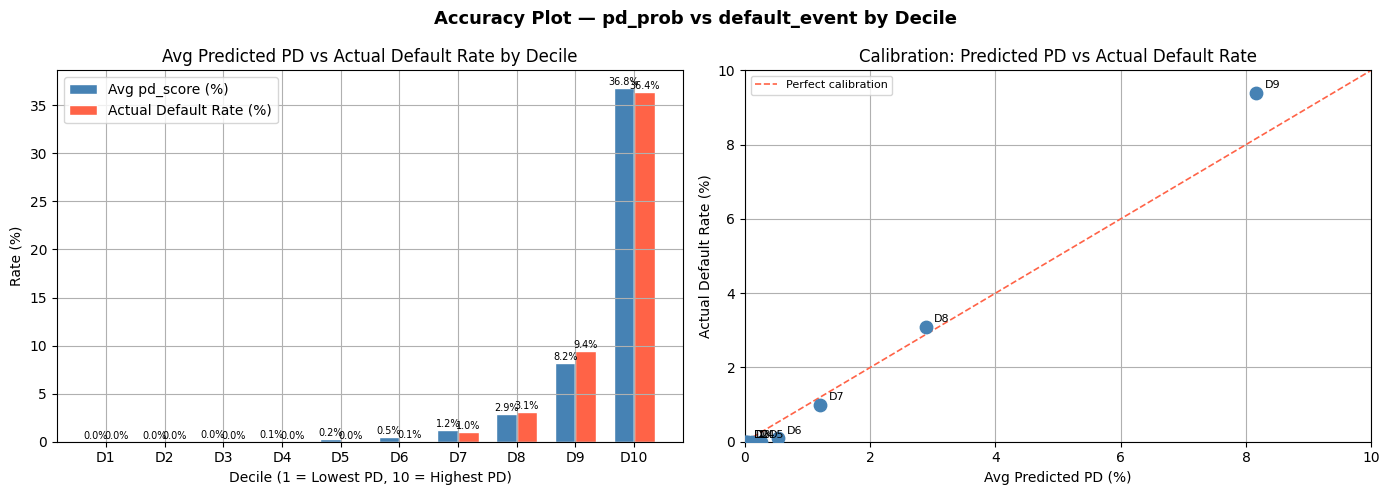


Decile Accuracy Table:
decile  count  avg_pd_score  actual_default_rate    diff
     1   1000        0.0000                0.000  0.0000
     2   1000        0.0002                0.000  0.0002
     3   1000        0.0005                0.000  0.0005
     4   1000        0.0011                0.000  0.0011
     5   1000        0.0025                0.000  0.0025
     6   1000        0.0053                0.001  0.0043
     7   1000        0.0121                0.010  0.0021
     8   1000        0.0289                0.031 -0.0021
     9   1000        0.0816                0.094 -0.0124
    10   1000        0.3679                0.364  0.0039


In [39]:
# ── Accuracy Plot: Average pd_prob vs Actual Default Rate by Decile ───────────
acc_df = df_scored[['pd_score', 'default_event']].copy()
acc_df['decile'] = pd.qcut(acc_df['pd_score'], q=10, labels=range(1, 11))

decile_stats = (
    acc_df.groupby('decile', observed=True)
    .agg(
        avg_pd_score=('pd_score', 'mean'),
        actual_default_rate=('default_event', 'mean'),
        count=('default_event', 'count'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = decile_stats['decile'].astype(int)
width = 0.35

# ── Panel 1: Grouped bar chart ────────────────────────────────────────────────
bars1 = axes[0].bar(x - width / 2, decile_stats['avg_pd_score'] * 100,
                    width=width, label='Avg pd_score (%)', color='steelblue', edgecolor='white')
bars2 = axes[0].bar(x + width / 2, decile_stats['actual_default_rate'] * 100,
                    width=width, label='Actual Default Rate (%)', color='tomato', edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels([f'D{i}' for i in x])
axes[0].set_xlabel('Decile (1 = Lowest PD, 10 = Highest PD)')
axes[0].set_ylabel('Rate (%)')
axes[0].set_title('Avg Predicted PD vs Actual Default Rate by Decile')
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7)

# ── Panel 2: Scatter / calibration line ───────────────────────────────────────
axes[1].scatter(decile_stats['avg_pd_score'] * 100,
                decile_stats['actual_default_rate'] * 100,
                color='steelblue', s=80, zorder=3)
for _, row in decile_stats.iterrows():
    axes[1].annotate(f"D{int(row['decile'])}",
                     (row['avg_pd_score'] * 100, row['actual_default_rate'] * 100),
                     textcoords='offset points', xytext=(6, 3), fontsize=8)

# Perfect calibration line — axis capped at 10%
lim_max = 10
axes[1].plot([0, lim_max], [0, lim_max], color='tomato', linestyle='--', lw=1.2, label='Perfect calibration')
axes[1].set_xlim(0, lim_max)
axes[1].set_ylim(0, lim_max)
axes[1].set_xlabel('Avg Predicted PD (%)')
axes[1].set_ylabel('Actual Default Rate (%)')
axes[1].set_title('Calibration: Predicted PD vs Actual Default Rate')
axes[1].legend(fontsize=8)

fig.suptitle('Accuracy Plot — pd_prob vs default_event by Decile', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nDecile Accuracy Table:')
decile_stats['diff'] = (decile_stats['avg_pd_score'] - decile_stats['actual_default_rate']).round(4)
print(decile_stats[['decile', 'count', 'avg_pd_score', 'actual_default_rate', 'diff']].round(4).to_string(index=False))

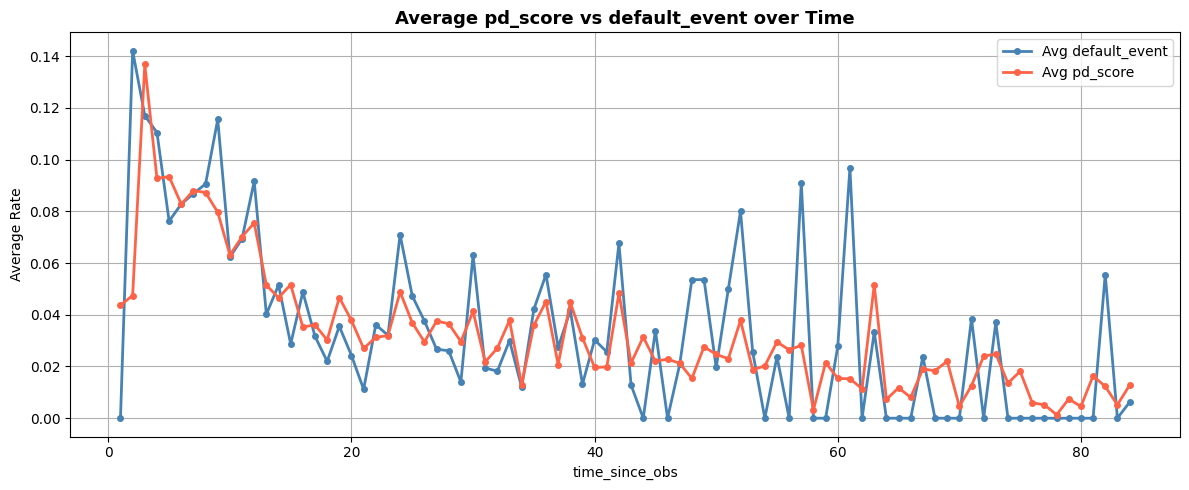

In [42]:
# ── Line Plot: Average pd_score and default_event over time_since_obs ─────────
trend = (
    df_scored.groupby('time_since_obs')
    .agg(
        avg_default_event=('default_event', 'mean'),
        avg_pd_score=('pd_score', 'mean'),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(trend['time_since_obs'], trend['avg_default_event'],
        color='steelblue', lw=2, marker='o', markersize=4, label='Avg default_event')
ax.plot(trend['time_since_obs'], trend['avg_pd_score'],
        color='tomato', lw=2, marker='o', markersize=4, label='Avg pd_score')

ax.set_xlabel('time_since_obs')
ax.set_ylabel('Average Rate')
ax.set_title('Average pd_score vs default_event over Time', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()